# **IBM Employee Attrition Analysis**  
#### _Why do employees leave? And what can we do about it?_

> _"Replacing an employee can cost up to twice their annual salary - excluding the hidden costs of lost productivity and team disruption."_

Employee attrition is not just an HR concern - it’s a **business risk**.  
When people leave, especially **frequently or unexpectedly**, productivity drops, projects slow down, and the **entire company feels the impact**.

This analysis uses the IBM HR Analytics dataset to uncover key factors influencing employee attrition and explores strategies to mitigate it.

# Notebook Roadmap
| Section | What We'll Do |
|--------|----------------|
| 🧭 **1. Explore the Dataset** | Understand the structure, size, and key features |
| 🧹 **2. Clean the Data** | Address missing values, correct data types, and prepare for analysis |
| 📊 **3. Visual EDA** | Use charts to uncover patterns and trends |
| 💡 **4. Hypothesis Testing** | Test ideas about what drives attrition |
| 🔧 **5. Preprocessing** | Prepare data for modeling (encoding, scaling, splitting) |
| 🤖 **6. Build Models** | Train and evaluate classifiers to predict attrition |

## Dataset Overview
The dataset contains information about employees, including:
- **Demographics**: Age, gender, marital status, etc.
- **Job-related information**: Job role, department, years at company, etc.
- **Performance metrics**: Job satisfaction, environment satisfaction, etc.
- **Compensation details**: Monthly income, stock options, etc.

## 🧭 **1. Exploring the Dataset**

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
# Import required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# To ignore warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# To change Scientific Notation to Decimal Format
pd.options.display.float_format = '{:.2f}'.format

In [3]:
# Reading the dataset
df = pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [4]:
# Display the first few rows of the dataset
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
# Display number of rows and columns of the dataset
df.shape

(1470, 35)

In [6]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
# Define categorical features based on domain knowledge and variable meaning
categorical_columns = [
    'Attrition', 'BusinessTravel', 'Department', 'Education', 'EducationField', 'EnvironmentSatisfaction',
    'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
    'Over18', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
    'WorkLifeBalance', 'StandardHours'  # Note: This column is constant across all rows
]

# Convert selected columns to 'category' data type to improve efficiency and prepare for analysis
df[categorical_columns] = df[categorical_columns].astype('category')

# Create a separate DataFrame containing only categorical features
df_categorical = df[categorical_columns]

# Identify numerical features by excluding the defined categorical columns
numerical_columns = df.columns.difference(categorical_columns).tolist()

# Create a separate DataFrame containing only numerical features
df_numerical = df[numerical_columns]

# Print the number of columns in each group for verification
print(f'Number of numerical columns: {df_numerical.shape[1]}')
print(f'Number of categorical columns: {df_categorical.shape[1]}')

Number of numerical columns: 16
Number of categorical columns: 19


In [8]:
# Describe each numerical column one by one
for col in df_numerical.columns:
    print("=" * 50)
    print(f"Summary for {col}:")
    print("=" * 50)
    # Display the summary with more readable formatting
    summary = df[col].describe()
    print(summary)
    print("-" * 50)

Summary for Age:
count   1470.00
mean      36.92
std        9.14
min       18.00
25%       30.00
50%       36.00
75%       43.00
max       60.00
Name: Age, dtype: float64
--------------------------------------------------
Summary for DailyRate:
count   1470.00
mean     802.49
std      403.51
min      102.00
25%      465.00
50%      802.00
75%     1157.00
max     1499.00
Name: DailyRate, dtype: float64
--------------------------------------------------
Summary for DistanceFromHome:
count   1470.00
mean       9.19
std        8.11
min        1.00
25%        2.00
50%        7.00
75%       14.00
max       29.00
Name: DistanceFromHome, dtype: float64
--------------------------------------------------
Summary for EmployeeCount:
count   1470.00
mean       1.00
std        0.00
min        1.00
25%        1.00
50%        1.00
75%        1.00
max        1.00
Name: EmployeeCount, dtype: float64
--------------------------------------------------
Summary for EmployeeNumber:
count   1470.00
mean    10

In [9]:
# Drop columns that do not provide useful information for analysis or modeling
# 'EmployeeNumber' is an ID column with no analytical value
# 'EmployeeCount' is a constant column (always 1)
df.drop(columns=['EmployeeNumber', 'EmployeeCount'], inplace=True)

# Also remove them from numerical_columns list if already defined
numerical_columns = [col for col in numerical_columns if col not in ['EmployeeNumber', 'EmployeeCount']]
df_numerical = df[numerical_columns]

In [10]:
# Describe each categorical column
df_categorical.describe()

,Attrition,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,Over18,OverTime,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance,StandardHours
count,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,5,6,4,2,4,5,9,4,3,1,2,2,4,4,4,1
top,No,Travel_Rarely,Research & Development,3,Life Sciences,3,Male,3,1,Sales Executive,4,Married,Y,No,3,3,0,3,80
freq,1233,1043,961,572,606,453,882,868,543,326,459,673,1470,1054,1244,459,631,893,1470


In [11]:
# Drop non-informative categorical columns
# 'Over18' has the same value for all rows (always 'Y')
# 'StandardHours' is also constant (always 80)
df.drop(columns=['Over18', 'StandardHours'], inplace=True)

# Remove from the categorical column list
categorical_columns = [col for col in categorical_columns if col not in ['Over18', 'StandardHours']]
df_categorical = df[categorical_columns]

In [12]:
# Final shape summary after cleaning and classification
print("=" * 60)
print("✅ Final Dataset Structure Summary")
print("=" * 60)
print(f"Full DataFrame shape        : {df.shape}")
print(f"Numerical DataFrame shape   : {df_numerical.shape}")
print(f"Categorical DataFrame shape : {df_categorical.shape}")
print("-" * 60)

✅ Final Dataset Structure Summary
Full DataFrame shape        : (1470, 31)
Numerical DataFrame shape   : (1470, 14)
Categorical DataFrame shape : (1470, 17)
------------------------------------------------------------


##  🧹 **2. Cleaning & Preparing the Data**

### **Detecting Duplicated Rows:**

In [13]:
# Count duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
print("=" * 50)
print("Duplicate Rows Summary")
print("=" * 50)
print(f"Total Duplicate Rows: {duplicate_count}")

Duplicate Rows Summary
Total Duplicate Rows: 0


> _There are no duplicate rows._

### **Handling Null Values:**

In [14]:
# Checking if there is any missing values
print("=" * 50)
print("Missing Values Summary")
print("=" * 50)
print(df.isnull().sum())

Missing Values Summary
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64


> _The dataset contains no missing values._

### **Identifying Invalid Values:**
* Incorrect data type formats
* Values that fall outside the valid range or expected values

In [15]:
# Display value counts for each categorical column to identify potential invalid entries
print("=" * 50)
print("Value Counts for Categorical Columns")
print("=" * 50)

for col in df_categorical:
    print("=" * 50)
    print(f"Column: {col}")
    print("=" * 50)
    print(df[col].value_counts().to_string(index=True, header=False))
    print("-" * 50)

Value Counts for Categorical Columns
Column: Attrition
No     1233
Yes     237
--------------------------------------------------
Column: BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
--------------------------------------------------
Column: Department
Research & Development    961
Sales                     446
Human Resources            63
--------------------------------------------------
Column: Education
3    572
4    398
2    282
1    170
5     48
--------------------------------------------------
Column: EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
--------------------------------------------------
Column: EnvironmentSatisfaction
3    453
4    446
2    287
1    284
--------------------------------------------------
Column: Gender
Male      882
Female    588
--------------------------------------------------
Column: JobIn

> _All categorical column values are valid and consistent with expected business definitions.
No corrections were necessary._

In [16]:
# Display min and max values to identify potential out-of-range entries
print("=" * 50)
print("Max and Min Values for Numerical Columns")
print("=" * 50)

for col in df_numerical.columns:
    max_value = df[col].max()
    min_value = df[col].min()
    print(f"Column: {col}")
    print(f"  Min : {min_value}")
    print(f"  Max : {max_value}")
    print("-" * 50)

Max and Min Values for Numerical Columns
Column: Age
  Min : 18
  Max : 60
--------------------------------------------------
Column: DailyRate
  Min : 102
  Max : 1499
--------------------------------------------------
Column: DistanceFromHome
  Min : 1
  Max : 29
--------------------------------------------------
Column: HourlyRate
  Min : 30
  Max : 100
--------------------------------------------------
Column: MonthlyIncome
  Min : 1009
  Max : 19999
--------------------------------------------------
Column: MonthlyRate
  Min : 2094
  Max : 26999
--------------------------------------------------
Column: NumCompaniesWorked
  Min : 0
  Max : 9
--------------------------------------------------
Column: PercentSalaryHike
  Min : 11
  Max : 25
--------------------------------------------------
Column: TotalWorkingYears
  Min : 0
  Max : 40
--------------------------------------------------
Column: TrainingTimesLastYear
  Min : 0
  Max : 6
-----------------------------------------------

> _All numerical features fall within reasonable business ranges._
> 
> _No extreme outliers or invalid values were detected at this stage._

## 📊 **3. Descriptive Statistics & Visual EDA**


#### **In this section, we explore the underlying patterns in the dataset using descriptive statistics and visual exploratory data analysis (EDA) techniques.**

- **The goal is to identify trends, anomalies, and key insights that help explain employee attrition.**

### **Attrition Distribution**


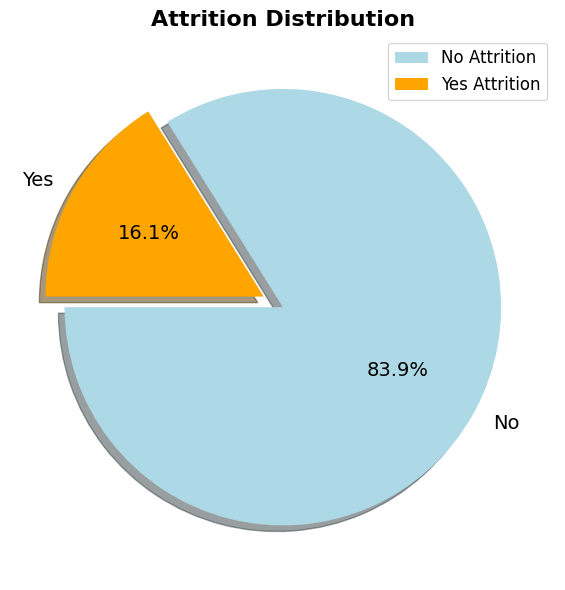

In [17]:
# Plotting the distribution of employee attrition
plt.figure(figsize=(8, 6))
attrition_counts = df['Attrition'].value_counts()

# Pie chart visualization
plt.pie(attrition_counts,
        autopct='%1.1f%%',
        colors=["lightblue", "orange"],
        labels=["No", "Yes"],
        explode=(0, 0.1),
        shadow=True,
        startangle=180,
        textprops={'fontsize': 14, 'color': 'black'})

plt.title("Attrition Distribution", fontsize=16, fontweight='bold')
plt.ylabel("")  # Clean look
plt.legend(["No Attrition", "Yes Attrition"], loc="upper right", fontsize=12)
plt.tight_layout()
plt.show()


> _Whether a 16% attrition rate is problematic depends on industry standards and company-specific factors.
For the purpose of this analysis, we will assume it represents a business concern and investigate it accordingly._

### **Job Role Distribution**

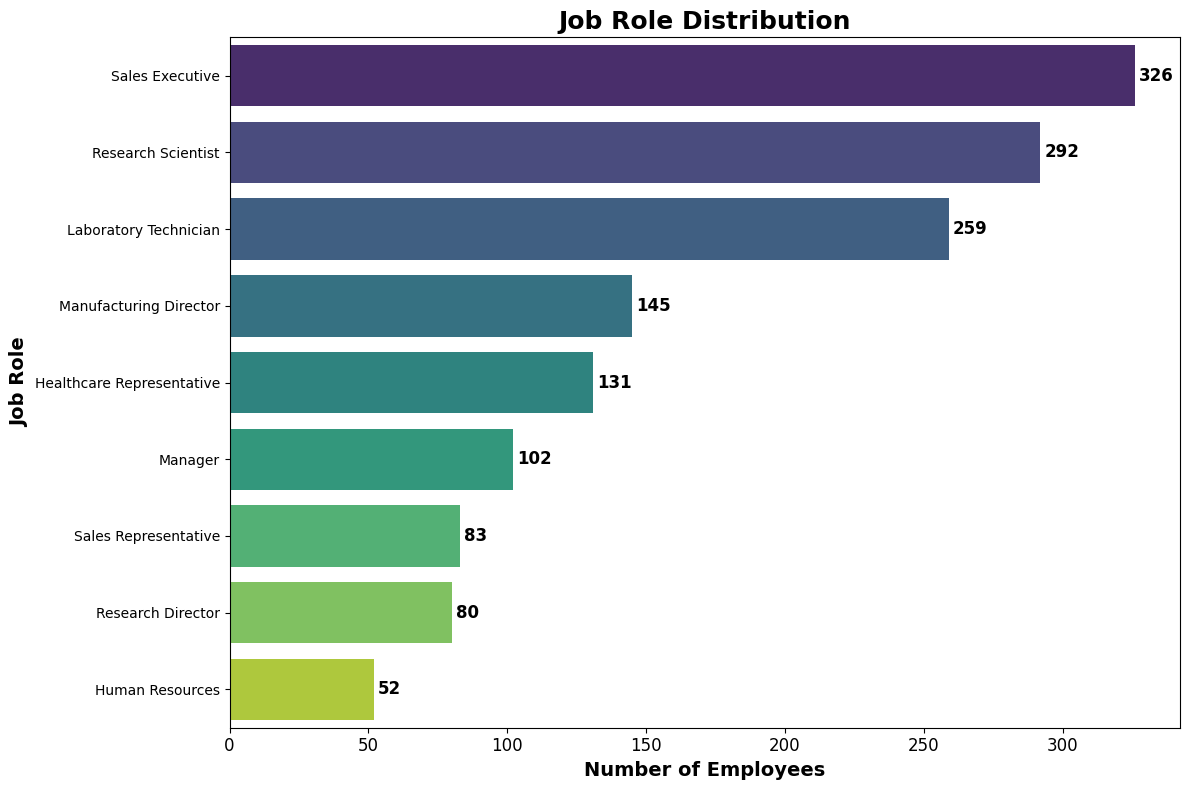

In [18]:
# Visualizing how employees are distributed across job roles

# Step 1: Get job roles sorted by employee counts, highest to lowest
jobrole_counts = df['JobRole'].value_counts()
sorted_jobroles = jobrole_counts.index.tolist()  # List of job roles sorted by count

# Step 2: Plot horizontal bar chart with job roles ordered by counts
plt.figure(figsize=(12, 8))
ax = sns.countplot(data=df, y='JobRole', palette='viridis', order=sorted_jobroles)

# Step 3: Add labels showing exact employee counts on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3,
                 fontsize=12, fontweight='bold', color='black')

# Step 4: Format the chart for readability
plt.title("Job Role Distribution", fontsize=18, fontweight='bold')
plt.ylabel("Job Role", fontsize=14, fontweight='bold')
plt.xlabel("Number of Employees", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.tight_layout()

# Step 5: Show the plot
plt.show()

**Job Role Distribution**
> _Sales Executive is the most common job role._
>
> _Human Resources has the fewest employees._
> 
Now that we understand how employees are distributed across job roles,
let's explore whether attrition is more common in specific roles.

### **Attrition with Job Role**

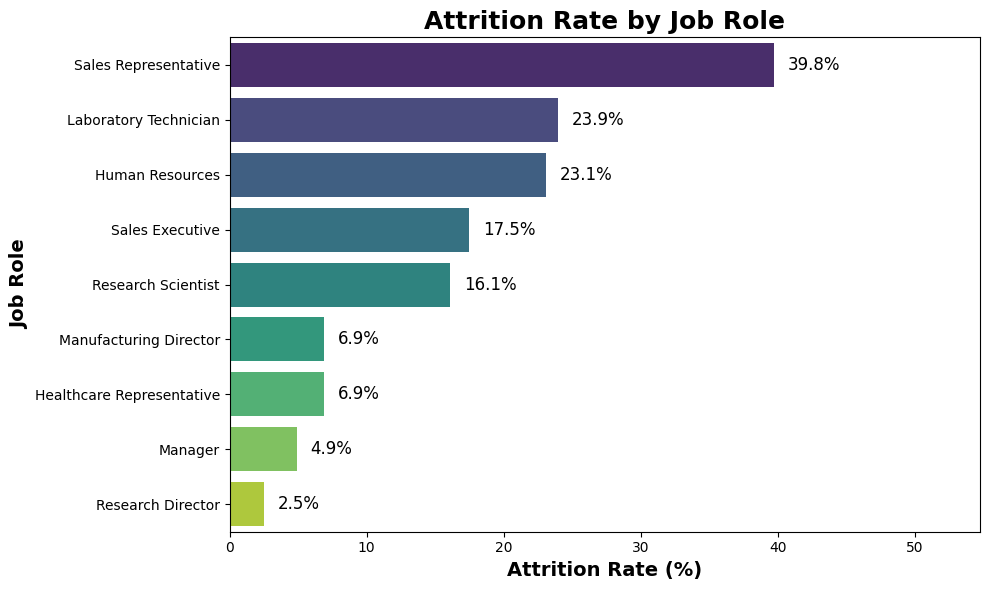

In [19]:
# Calculate attrition percentage per JobRole
attrition_pct = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').mean())

# Sort job roles by attrition rate descending
sorted_jobroles = attrition_pct.sort_values(ascending=False).index

plt.figure(figsize=(10, 6))

# Use order param to explicitly set bar order by sorted job roles
sns.barplot(x=attrition_pct.values * 100, y=attrition_pct.index, order=sorted_jobroles, palette="viridis")

plt.xlabel("Attrition Rate (%)", fontsize=14, fontweight='bold')
plt.ylabel("Job Role", fontsize=14, fontweight='bold')
plt.title("Attrition Rate by Job Role", fontsize=18, fontweight='bold')

# Annotate bars with attrition rate
for i, job in enumerate(sorted_jobroles):
    pct = attrition_pct[job] * 100
    plt.text(pct + 1, i, f'{pct:.1f}%', va='center', fontsize=12, color='black')

plt.xlim(0, max(attrition_pct.values * 100) + 15)
plt.tight_layout()
plt.show()

**Observation:**

It’s interesting to see that the **Sales Representative** role has the highest attrition rate at around **40%**, 
while the **Research Director** role has one of the lowest rates at about **2%**.

This suggests there may be underlying issues specifically affecting the Sales Representative position. 

Further investigation will help uncover the root causes behind this disparity.

### **Business Travel Distribution**

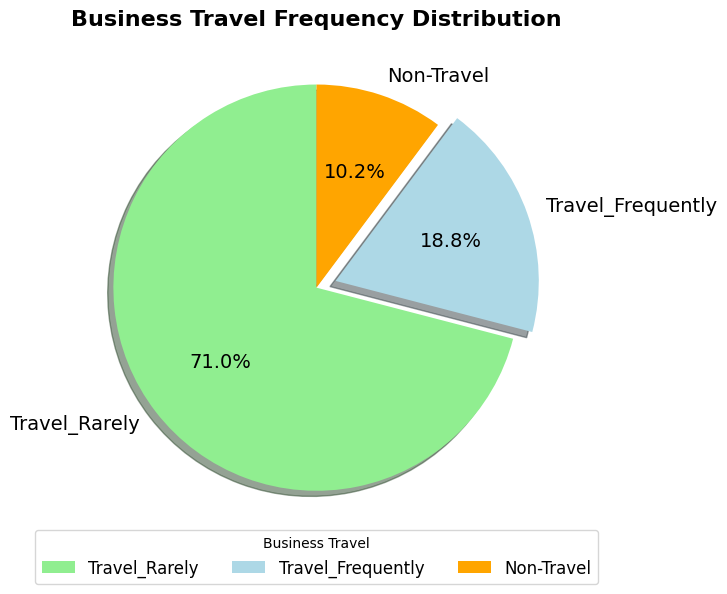

In [20]:
# Visualizing Business Travel distribution
plt.figure(figsize=(8, 6))
bt_counts = df['BusinessTravel'].value_counts()

# Pie chart
plt.pie(bt_counts, 
        autopct='%1.1f%%', 
        colors=["lightgreen", "lightblue", "orange"],
        labels=bt_counts.index, 
        explode=(0, 0.1, 0),  # Emphasize "Travel_Frequently"
        shadow=True,
        startangle=90,
        textprops={'fontsize': 14, 'color': 'black'})

plt.title("Business Travel Frequency Distribution", fontsize=16, fontweight='bold')
plt.ylabel("")
plt.legend(bt_counts.index, 
           loc="lower center", 
           bbox_to_anchor=(0.5, -0.1), 
           fontsize=12, 
           title="Business Travel", 
           ncol=3)
plt.tight_layout()
plt.show()

> _Most employees travel rarely, but we’ll check if frequent travel is linked to higher attrition next._

### **Attrition with Business Travel**

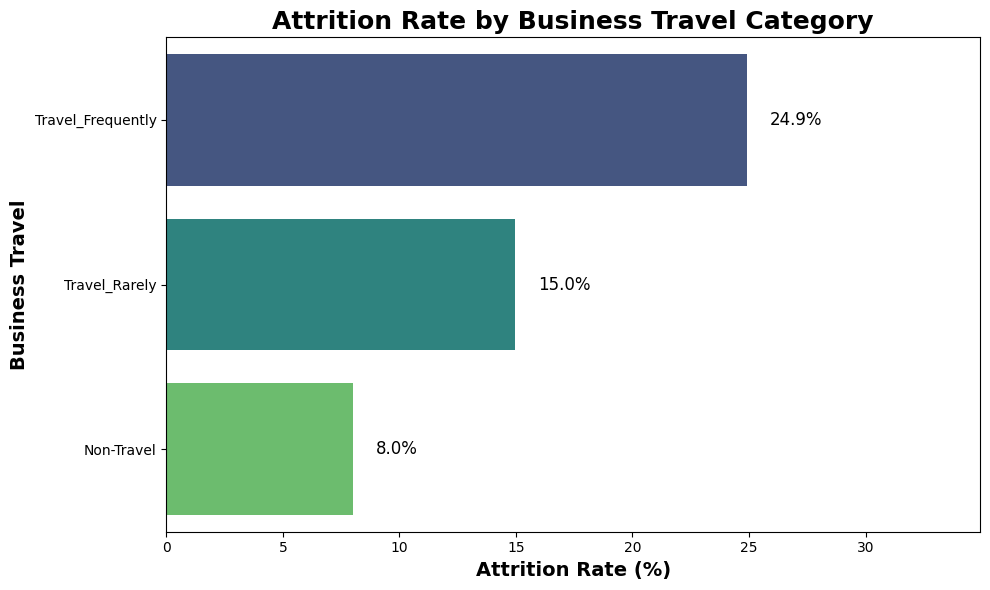

In [21]:
# Visualizing attrition rate across different business travel categories

# Calculate attrition rate (%) per business travel type, sorted from highest to lowest
bt_attrition_rate = df.groupby('BusinessTravel')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100 )
bt_attrition_rate = bt_attrition_rate.sort_values(ascending=False) 

# Create a horizontal bar plot showing attrition rate by travel type
plt.figure(figsize=(10, 6))
palette = sns.color_palette("viridis", n_colors=len(bt_attrition_rate))

sns.barplot(
    x=bt_attrition_rate.values,
    y=bt_attrition_rate.index.tolist(),
    palette=palette
)

# Format chart aesthetics
plt.xlabel("Attrition Rate (%)", fontsize=14, fontweight="bold")
plt.ylabel("Business Travel", fontsize=14, fontweight="bold")
plt.title("Attrition Rate by Business Travel Category", fontsize=18, fontweight="bold")

# Annotate each bar with attrition % 
for i, travel_type in enumerate(bt_attrition_rate.index):
    rate = bt_attrition_rate[travel_type]
    plt.text(rate + 1, i, f"{rate:.1f}%", va='center', fontsize=12, color='black')
    
# final layout tweaks
plt.xlim(0, bt_attrition_rate.max() + 10)
plt.tight_layout()
plt.show()

> Employees who travel frequently have the highest attrition rate at 24%.
> 
> This raises a suspicion:
> 
> could the high attrition rate of Sales Representatives be linked to frequent travel?
> 
> Let’s investigate how job roles relate to travel frequency next.

### Business travel frequantly distribution with Job Role

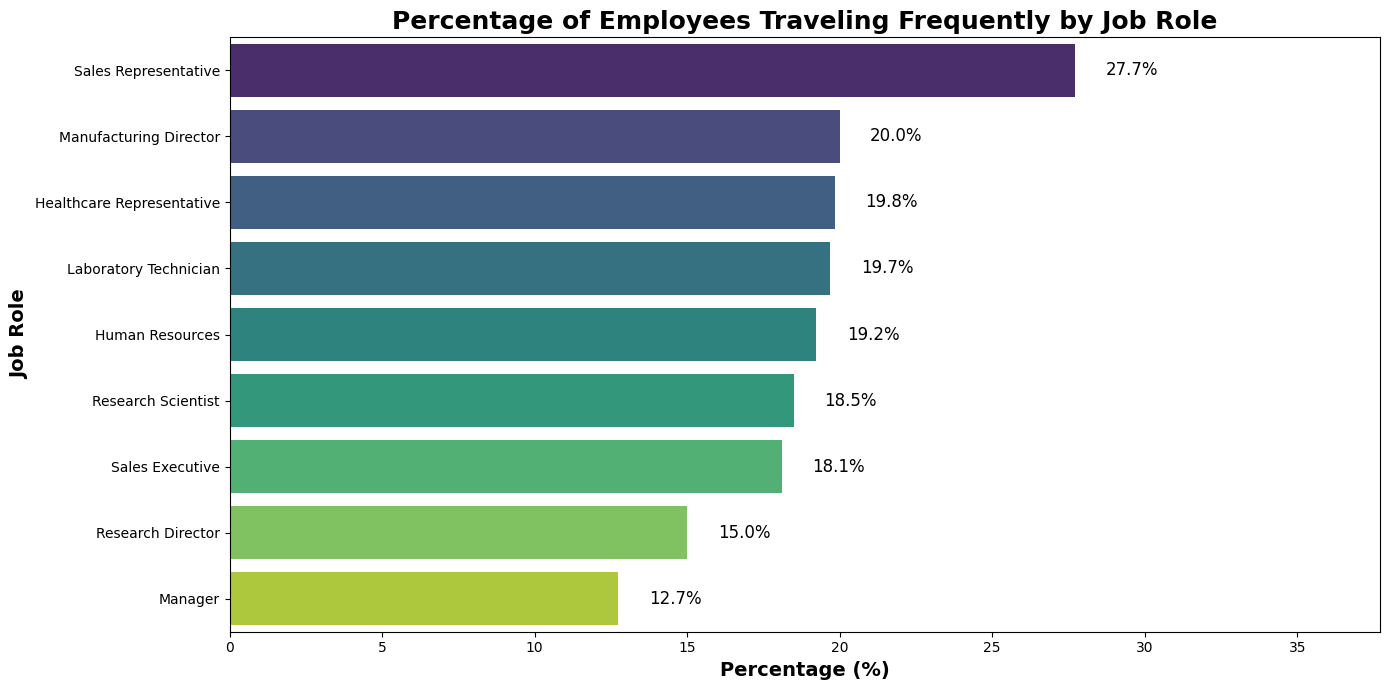

In [22]:
# # Analyzing the percentage of frequent travelers within each job role

# Count number of employees who travel frequently, by job role
freq_travel_counts = df[df['BusinessTravel'] == 'Travel_Frequently'].groupby('JobRole').size()

# Get total number of employees per job role
total_jobrole_counts = df.groupby('JobRole').size()

# Calculate the percentage of frequent travelers in each job role
freq_travel_pct = (freq_travel_counts / total_jobrole_counts * 100).sort_values(ascending=False)

# Create a bar plot showing the travel frequency percentage by job ro
plt.figure(figsize=(14,7))
palette = sns.color_palette("viridis", n_colors=len(freq_travel_pct))
sns.barplot(
    x=freq_travel_pct.values,
    y=freq_travel_pct.index.tolist(),
    palette=palette
)

# Add chart title and axis labels
plt.xlabel("Percentage (%)", fontsize=14, fontweight='bold')
plt.ylabel("Job Role", fontsize=14, fontweight='bold')
plt.title("Percentage of Employees Traveling Frequently by Job Role", fontsize=18, fontweight='bold')


# Annotate values on bars
for i, job_role in enumerate(freq_travel_pct.index):
    rate = freq_travel_pct[job_role]
    plt.text(rate + 1, i, f"{rate:.1f}%", va='center', fontsize=12, color='black')
    
# final layout tweaks
plt.xlim(0, freq_travel_pct.max() + 10)
plt.tight_layout()
plt.show()

> _As suspected, Sales Representatives have the highest rate of frequent travel, with 27% of them traveling frequently._
>
> _This strengthens the hypothesis that frequent travel may be a key driver behind their high attrition rate._

While Sales Representatives have the highest travel frequency,
other roles with similarly high travel rates (around 20%) don’t show the same attrition levels.

This suggests that frequent travel alone isn’t the full story -- there must be other influencing factors.

> _Next, I’ll explore whether Monthly income is playing a role in this pattern._

### **Monthly Income Distribution**


Skewness of Monthly Income: 1.37
Mean:  6502.9 | Median:  4919.0
Min:  1009.0 | Q1:  2911.0 | Q3: 8379.0 | Max:  19999.0


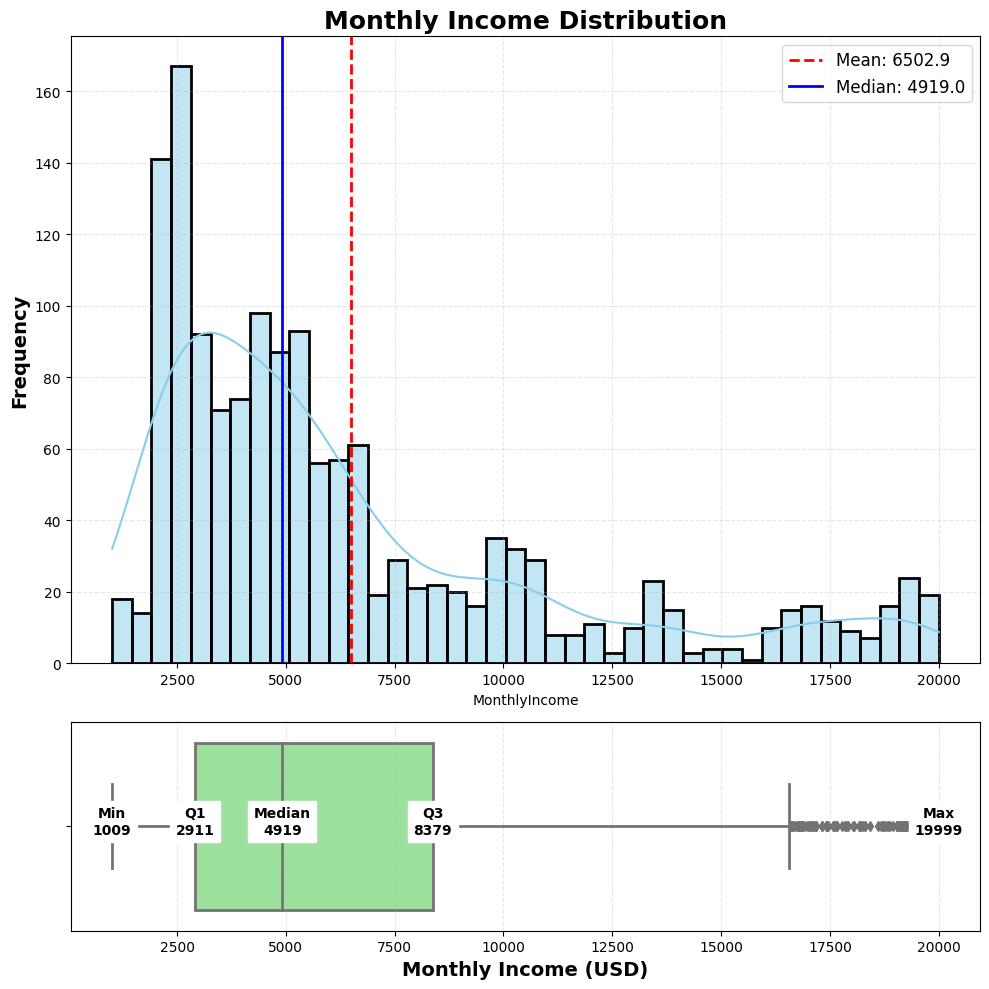

In [23]:
# Analyzing the distribution of Monthly Income

# Calculate descriptive statistics for MonthlyIncome
income_skewness = df['MonthlyIncome'].skew()
income_mean = df['MonthlyIncome'].mean()
income_median = df['MonthlyIncome'].median()
income_min = df['MonthlyIncome'].min()
income_q1 = df['MonthlyIncome'].quantile(0.25)
income_q3 = df['MonthlyIncome'].quantile(0.75)
income_max = df['MonthlyIncome'].max()

# Display key summary values
print(f"Skewness of Monthly Income: {income_skewness:.2f}")
print(f"Mean: {income_mean: .1f} | Median: {income_median: .1f}")
print(f"Min: {income_min: .1f} | Q1: {income_q1: .1f} | Q3:{income_q3: .1f} | Max: {income_max: .1f}")

# Create a combined histogram + boxplot for better distribution analysis
fig, ax = plt.subplots(2, 1, figsize=(10,10), gridspec_kw={'height_ratios':[3,1]})

# Histogram with KDE
sns.histplot(data=df, x='MonthlyIncome', kde=True, bins=42, color='skyblue', linewidth=2, ax=ax[0])
ax[0].axvline(income_mean, color='red', linestyle='--', linewidth=2, label=f"Mean: {income_mean:.1f}")
ax[0].axvline(income_median, color='blue', linestyle='-', linewidth=2, label=f"Median: {income_median:.1f}")
ax[0].set_title("Monthly Income Distribution", fontsize=18, fontweight='bold')
ax[0].set_ylabel("Frequency", fontsize=14, fontweight='bold')
ax[0].legend(fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.3)

# Boxplot
sns.boxplot(data=df, x='MonthlyIncome', ax=ax[1], color='lightgreen', linewidth=2)
ax[1].set_xlabel("Monthly Income (USD)", fontsize=14, fontweight='bold')
ax[1].grid(True, axis='x', linestyle='--', alpha=0.3)

# Annotate quartiles and extremes on the boxplot
for val, label in zip([income_min, income_q1, income_median, income_q3, income_max],
                      ['Min', 'Q1', 'Median', 'Q3', 'Max']):
    ax[1].text(val, 0.05, f'{label}\n{val:.0f}', ha='center', va='bottom',fontsize=10, fontweight='bold', backgroundcolor='white')

# Final layout adjustment
plt.tight_layout()
plt.show()

> The Monthly Income distribution is clearly right-skewed, with several extreme outliers.
> 
> This suggests that while a few employees earn very high salaries, the majority earn much less.
> 
> As the saying goes, “money is always the problem” — so let’s investigate whether income is related to attrition.

### **Attrition with Monthly Income**

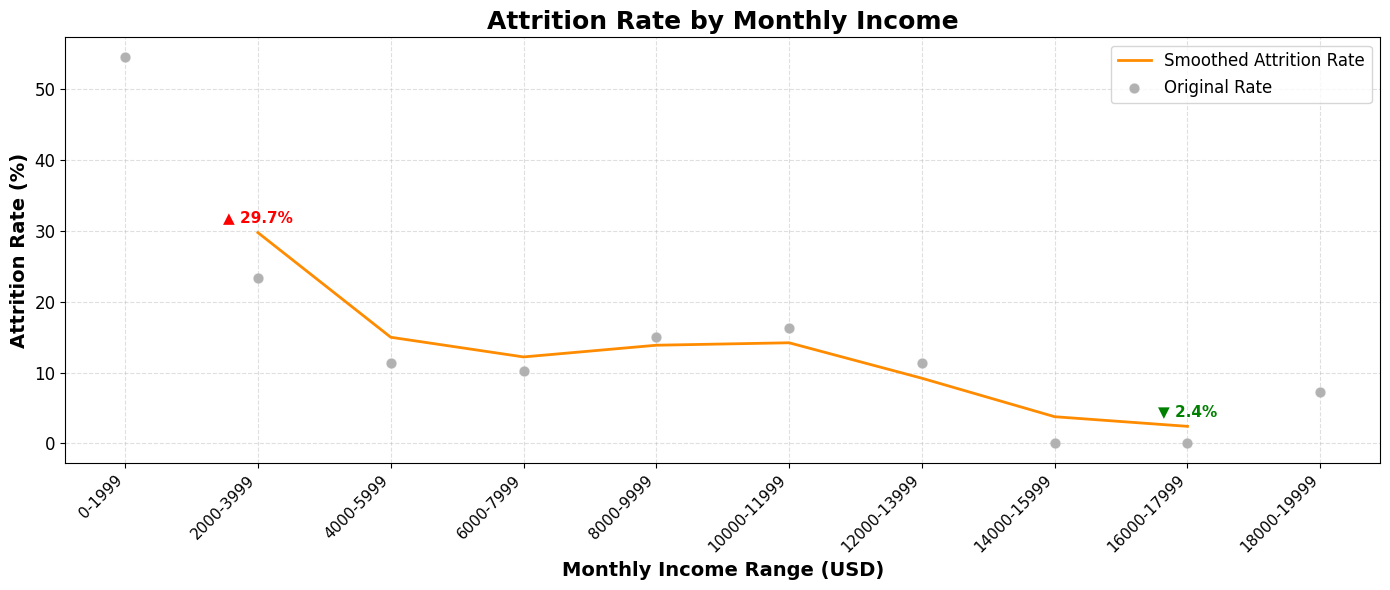

In [24]:
# Exploring the relationship between Monthly Income and Attrition

# Create income bins (e.g., 0–1999, 2000–3999, ...)
bin_width = 2000
max_income = int(df['MonthlyIncome'].max())
new_df = df.copy()
new_df['IncomeBin'] = pd.cut(df['MonthlyIncome'], bins=range(0, max_income + bin_width, bin_width))

# Calculate attrition rate (%) per income bin
income_attrition = new_df.groupby('IncomeBin')['Attrition'].value_counts(normalize=True).unstack()
attrition_rate = income_attrition['Yes'] * 100

# Prepare dataframe for plotting
attrition_df = attrition_rate.reset_index()
attrition_df['IncomeRange'] = attrition_df['IncomeBin'].apply(lambda x: f'{int(x.left)}-{int(x.right - 1) }')

# Apply smoothing with rolling mean (centered window of 3)
attrition_df['SmoothedRate'] = attrition_df['Yes'].rolling(window=3, center=True).mean()

# Plot smoothed line + raw points
plt.figure(figsize=(14,6))

# Smoothed line plot
sns.lineplot(data=attrition_df, x='IncomeRange', y='SmoothedRate',
            label='Smoothed Attrition Rate', color='darkorange', linewidth=2)

# Raw attrition rates
sns.scatterplot(data=attrition_df, x='IncomeRange', y='Yes',
               label='Original Rate', color='gray', s=60, alpha=0.6)

# Chart formatting
plt.title("Attrition Rate by Monthly Income", fontsize=18, fontweight='bold')
plt.xlabel("Monthly Income Range (USD)", fontsize=14, fontweight='bold')
plt.ylabel("Attrition Rate (%)", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=12)

# Annotate highest and lowest smoothed points
max_idx = attrition_df['SmoothedRate'].idxmax()
min_idx = attrition_df['SmoothedRate'].idxmin()

plt.text(x=attrition_df.loc[max_idx, 'IncomeRange'],
         y=attrition_df.loc[max_idx, 'SmoothedRate'] + 1.5,
         s=f"▲ {attrition_df.loc[max_idx, 'SmoothedRate']:.1f}%",
         color='red', ha='center', fontweight='bold', fontsize=11)

plt.text(x=attrition_df.loc[min_idx, 'IncomeRange'],
         y=attrition_df.loc[min_idx, 'SmoothedRate'] + 1.5,
         s=f"▼ {attrition_df.loc[min_idx, 'SmoothedRate']:.1f}%",
         color='green', ha='center', fontweight='bold', fontsize=11)

# Final layout
plt.tight_layout()
plt.show()

Now that we've seen how low income is associated with higher attrition, it's time to dig deeper and ask:
**Are some job roles inherently low-paying?**

> _The distribution of MonthlyIncome is **positively skewed**, meaning a few employees earn significantly more than the rest._
>
> _As a result, the mean income would be inflated by high **outliers** and would not accurately reflect the typical salary._
>
> _In such cases, the **median** is a much better measure of central tendency, as it is robust to outliers and provides a clearer picture of what most employees are earning._
>
> _This is why we use the median income per Job Role to compare salary levels across roles more reliably._

### **MonthlyIncome with JobRole**

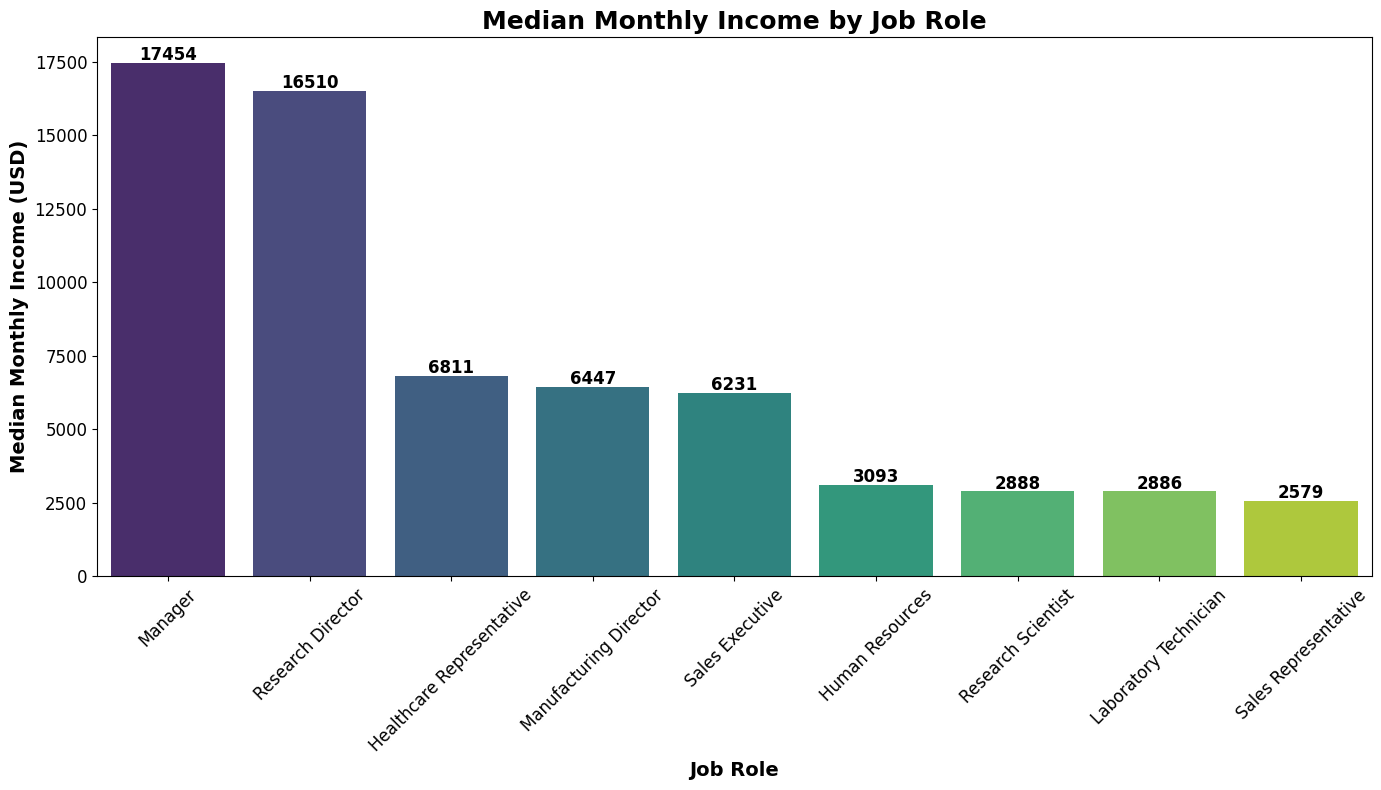

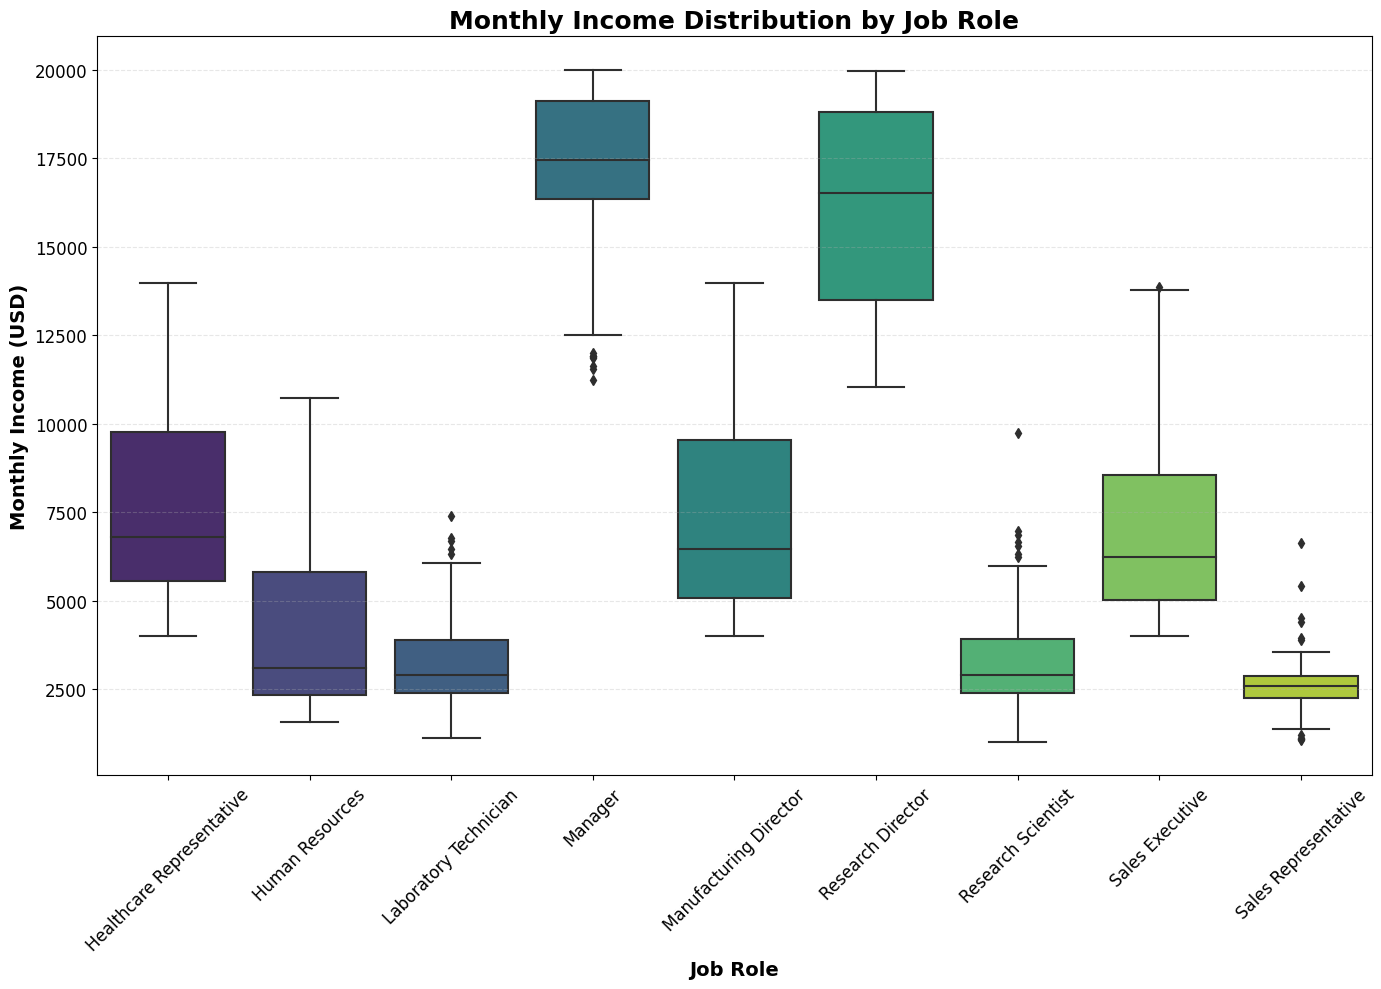

In [25]:
# ---------------------------------------------------------
# Bar Plot: Median Monthly Income per Job Role
# ---------------------------------------------------------

# Calculate median income per Job Role
median_income_by_role = df.groupby('JobRole')['MonthlyIncome'].median().sort_values(ascending=False)

# Create bar plot to show median income
plt.figure(figsize=(14, 8))
sns.barplot(x=median_income_by_role.index.tolist(), 
            y=median_income_by_role.values, 
            palette='viridis')

# Customize plot appearance
plt.title('Median Monthly Income by Job Role', fontsize=18, fontweight='bold')
plt.xlabel('Job Role', fontsize=14, fontweight='bold')
plt.ylabel('Median Monthly Income (USD)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Annotate bars with exact median values
for i, val in enumerate(median_income_by_role.values):
    plt.text(i, val + 100, f'{val:.0f}', ha='center', fontsize=12, fontweight='bold')

# Final layout
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Box Plot: Full Monthly Income Distribution per Job Role
# ---------------------------------------------------------

plt.figure(figsize=(14, 10))

# Create boxplot to visualize distribution and outliers
sns.boxplot(data=df, x='JobRole', y='MonthlyIncome', palette='viridis')

# Customize appearance
plt.title('Monthly Income Distribution by Job Role', fontsize=18, fontweight='bold')
plt.xlabel('Job Role', fontsize=14, fontweight='bold')
plt.ylabel('Monthly Income (USD)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Final layout
plt.tight_layout()
plt.show()


Income Disparity May Explain Attrition in Sales Roles

> By examining the median monthly income by job role, we notice a **clear pattern**:
>
> The **Sales Representative** position has the **lowest income** among all roles in the company.



## **💡 4. Hypothesis Formation & Testing**

### Insight: Connecting the Dots on Job Role & Attrition

* **Sales Representatives** have the **highest attrition rate** at **40%**, far above other roles.
* Employees who **travel frequently** show an attrition rate of **24%** the highest among travel categories.
* **Lower income** bands are strongly associated with **higher attrition rates**.
* Sales Representatives are the **most frequent travelers** in the company.
* They also have the **lowest median income** among all job roles.

---

### Hypothesis:

> The **high attrition rate** among Sales Representatives may be driven by a **combination of factors**:
>
> * **Low compensation**
> * **Frequent business travel**
> * Potentially higher **job stress** or lack of work-life balance


### Hypothesis Check: Job Role × Business Travel

To further investigate the **high attrition rate among Sales Representatives**,
I will visualize a **matrix (heatmap)** that shows the **attrition rate for each combination** of:

* **Job Role**
* **Business Travel Frequency**

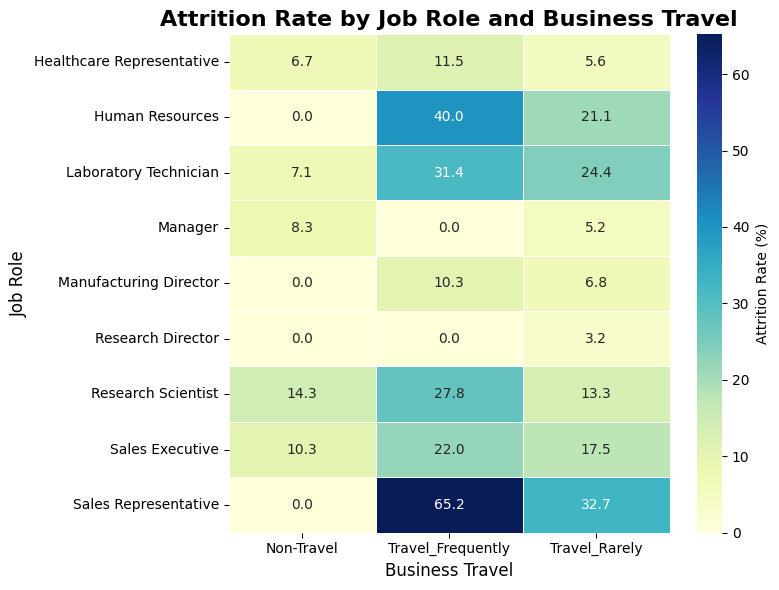

In [26]:
new_df = df.copy()

# Group by JobRole and BusinessTravel and calculate attrition rate
pivot_bt = new_df.groupby(['JobRole', 'BusinessTravel'])['Attrition'].apply(lambda x: (x == 'Yes').mean()).unstack()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_bt * 100, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Attrition Rate (%)'})
plt.title("Attrition Rate by Job Role and Business Travel", fontsize=16, fontweight='bold')
plt.xlabel("Business Travel", fontsize=12)
plt.ylabel("Job Role", fontsize=12)
plt.tight_layout()
plt.show()

### 💥 Sales Representatives Who Travel Frequently Are at Highest Risk

> The heatmap reveals that **Sales Representatives** who **travel frequently** have an attrition rate of **\~65%**
> 
> the **highest among all job role and travel frequency combinations**.


### Hypothesis Check: Job Role × Monthly Income

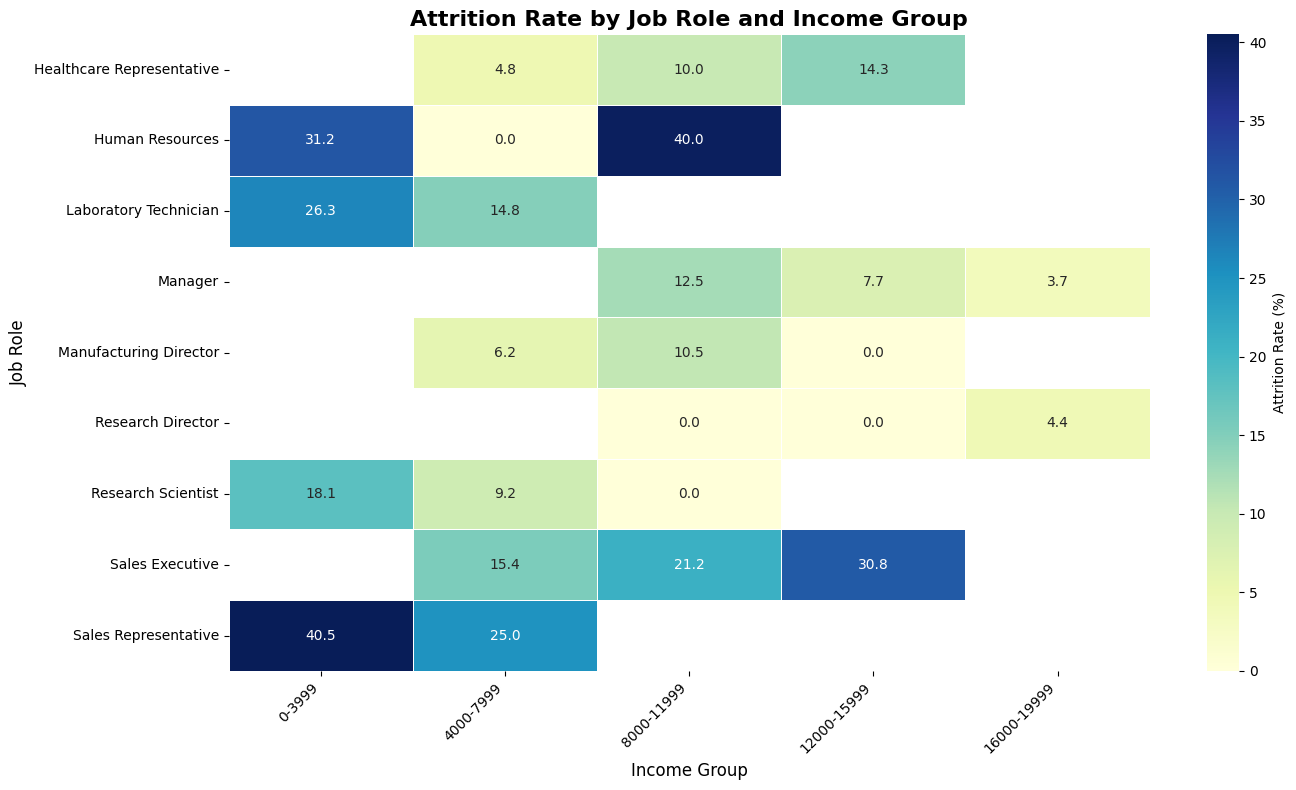

In [27]:
# Bin MonthlyIncome into ranges of 4000
bin_width = 4000
max_income = int(df['MonthlyIncome'].max())
new_df['IncomeGroup'] = pd.cut(df['MonthlyIncome'],
                           bins=range(0, max_income + bin_width, bin_width),
                           labels=[f'{i}-{i+bin_width-1}' for i in range(0, max_income, bin_width)],
                           right=False)

# Group by JobRole and IncomeGroup and calculate attrition rate
pivot_income = new_df.groupby(['JobRole', 'IncomeGroup'])['Attrition'].apply(lambda x: (x == 'Yes').mean()).unstack()

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_income * 100, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Attrition Rate (%)'})
plt.title("Attrition Rate by Job Role and Income Group", fontsize=16, fontweight='bold')
plt.xlabel("Income Group", fontsize=12)
plt.ylabel("Job Role", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Low Income Deepens Attrition Among Sales Representatives

> In the **Job Role × Income Group** heatmap, **Sales Representatives** in the **lowest income bracket (< 4000 USD)**
> show an attrition rate of **\~40%**, topping all other income groups across job roles.

* This confirms that **low pay is a major attrition driver**, especially for Sales Reps.
* When combined with **frequent travel**, the stress + financial dissatisfaction likely becomes unsustainable.


## 🧠 Final Observation Summary

After a detailed analysis of the dataset, several strong patterns emerged:

### High Attrition Segments Identified:

* **Sales Representatives** have the **highest attrition rate** among all job roles (**\~40%**).
* Employees who **travel frequently** have a significantly **higher attrition rate (\~24%)** compared to others.
* **Sales Representatives** are the most likely to **travel frequently** (**\~27%** of them do).
* **Low-income employees** (especially those earning **< 4000 USD**) show a **notably high attrition rate**.
* Among **Sales Reps with low income and frequent travel**, attrition rate is **\~65%**, the highest of any segment analyzed.

### Hypothesis Confirmed:

> Attrition is not random - it’s **concentrated** among employees who face a **combination of financial pressure** and **job-related stress**, particularly in sales roles.

### Key Insight:

* The **intersection of Job Role, Income, and Travel Frequency** is a **critical driver** of attrition.
* **Sales Reps** with **low pay** and **frequent travel** experience a **“perfect storm”** of attrition triggers.


## 🔧 **5. Data Preprocessing**


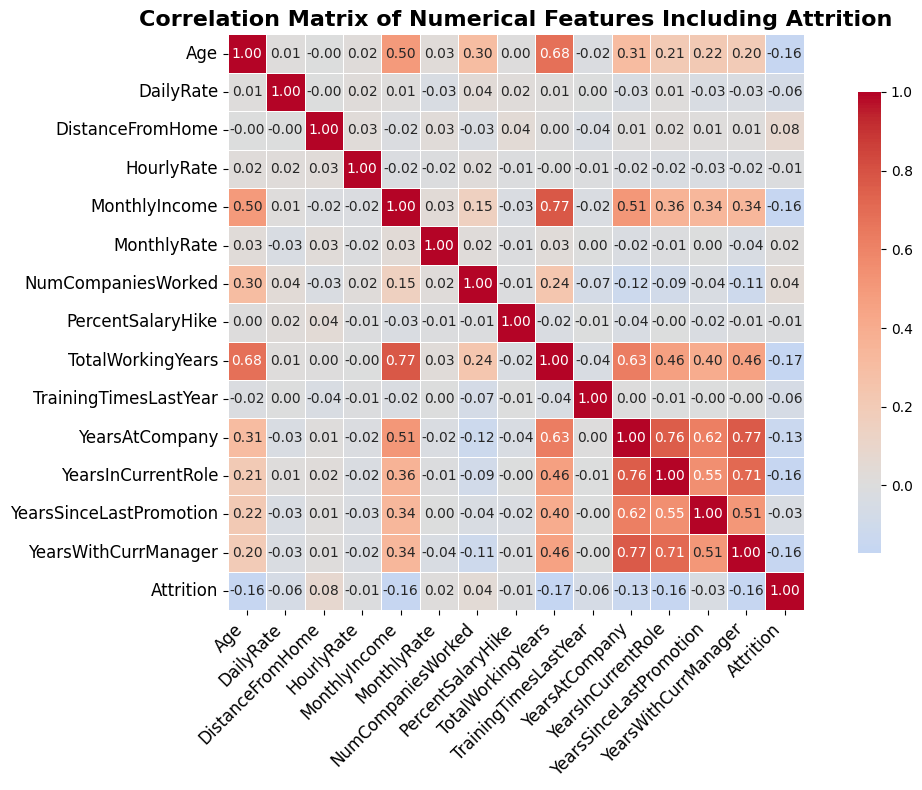

In [28]:
# Create a copy of numerical df to avoid modifying original
num_df_with_target = df_numerical.copy()

# Convert Attrition to numeric: Yes=1, No=0
num_df_with_target['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

plt.figure(figsize=(12, 8))
corr = num_df_with_target.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix of Numerical Features Including Attrition", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

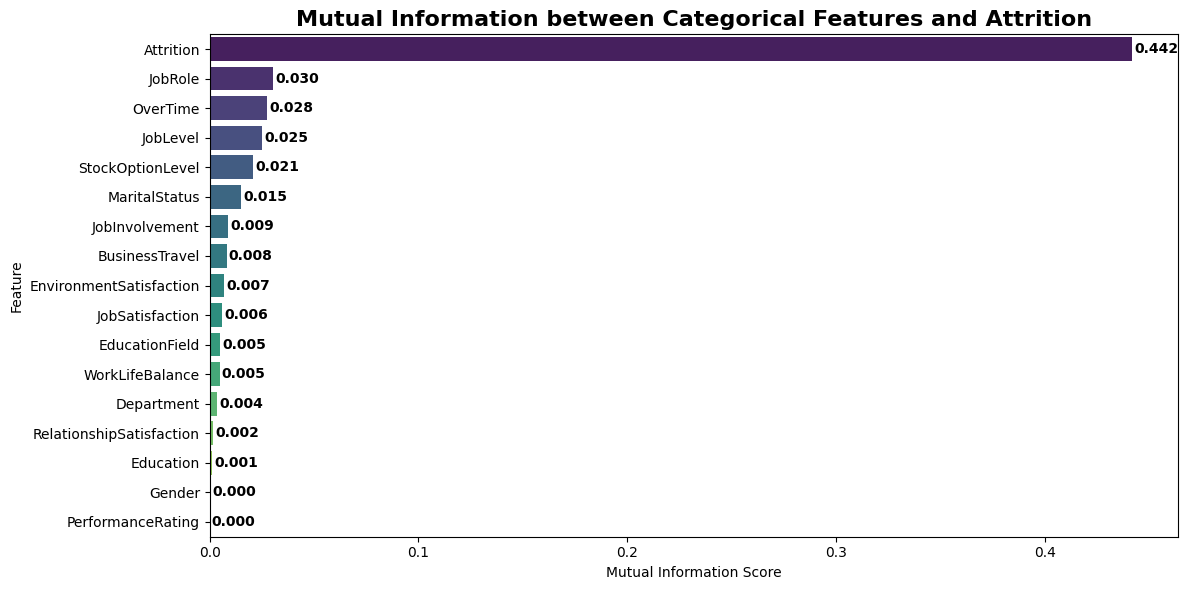

In [29]:
# Prepare target variable: Attrition encoded as 0/1
y = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Encode categorical features as integer codes
X_cat = df_categorical.apply(lambda x: x.cat.codes)

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_cat, y, discrete_features=True, random_state=42)

# Create DataFrame for plotting
mi_df = pd.DataFrame({'Feature': X_cat.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=mi_df, x='MI Score', y='Feature', palette='viridis')

# Add value labels on bars
for i, v in enumerate(mi_df['MI Score']):
    ax.text(v + 0.001, i, f"{v:.3f}", color='black', fontweight='bold', va='center')

plt.title('Mutual Information between Categorical Features and Attrition', fontsize=16, fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 🤖 **6. Predictive Modeling**

### Data Splitting:

In [30]:
# --- Target Variable ---
y = df['Attrition'].map({'Yes': 1, 'No': 0})  # Binary encoding

# --- Drop Useless Columns ---
df_model = df.drop(columns=[
    'Attrition'])

# --- Separate Column Types ---
categorical_features = df_model.select_dtypes(include='category').columns.tolist()
numerical_features = df_model.select_dtypes(include='number').columns.tolist()

# Just a safety check in case something got left out
print(f"Categorical: {categorical_features}")
print(f"Numerical: {numerical_features}")

Categorical: ['BusinessTravel', 'Department', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']
Numerical: ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [31]:
# --- Categorical Pipeline ---
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# --- Numerical Pipeline ---
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# --- Combine Transformers ---
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

In [32]:
# --- Apply preprocessing to train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    df_model, y, test_size=0.2, random_state=42, stratify=y
)

# --- Fit and transform data (for models that don’t use pipeline directly like XGBoost) ---
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### Model Selection & Training:

In [33]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("=" * 60)
    print(f"📌 Model: {name}")
    print("=" * 60)
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    print("-" * 60)

In [34]:
# 1. Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_processed, y_train)
evaluate_model("Logistic Regression", log_model, X_test_processed, y_test)

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)
evaluate_model("Random Forest", rf_model, X_test_processed, y_test)

# 3. XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_processed, y_train)
evaluate_model("XGBoost", xgb_model, X_test_processed, y_test)

📌 Model: Logistic Regression
[[239   8]
 [ 29  18]]

Classification Report:
              precision    recall  f1-score   support

           0      0.892     0.968     0.928       247
           1      0.692     0.383     0.493        47

    accuracy                          0.874       294
   macro avg      0.792     0.675     0.711       294
weighted avg      0.860     0.874     0.859       294

ROC AUC Score: 0.8430
------------------------------------------------------------
📌 Model: Random Forest
[[242   5]
 [ 43   4]]

Classification Report:
              precision    recall  f1-score   support

           0      0.849     0.980     0.910       247
           1      0.444     0.085     0.143        47

    accuracy                          0.837       294
   macro avg      0.647     0.532     0.526       294
weighted avg      0.784     0.837     0.787       294

ROC AUC Score: 0.7455
------------------------------------------------------------
📌 Model: XGBoost
[[242   5]
 [ 35 

## **Model Performance Summary**

We trained and evaluated three classification models to predict employee attrition:

| Model               | Accuracy  | ROC AUC   | Precision (Yes) | Recall (Yes) | F1-Score (Yes) |
| ------------------- | --------- | --------- | --------------- | ------------ | -------------- |
| Logistic Regression | **87.4%** | **0.843** | 0.692           | 0.383        | 0.493          |
| Random Forest       | 83.7%     | 0.745     | 0.444           | **0.085**    | 0.143          |
| XGBoost             | 86.4%     | 0.775     | **0.706**       | **0.255**    | **0.375**      |

---

### **Key Observations:**

* **Logistic Regression** had the best balance between overall performance and class recall, achieving the **highest ROC AUC (0.843)** and better recall for attrition than the tree-based models.
* **Random Forest** performed well on the majority class but **struggled significantly** with identifying employees who left (very low recall: 8.5%).
* **XGBoost** showed **improved precision (70%)** on the positive class and better recall than Random Forest, making it **the strongest model in terms of identifying attrition cases**, though still not perfect.

## Thank you for taking some time to review this analysis!😊